<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Raw Dataset](#raw-dataset)
- [Reduced Dataset](#reduced-dataset)

</div>

##### **IMPORTANT**:
- This assumes that you have downloaded the raw dataset, [RADIOML 2018.01A from Deepsig](https://www.deepsig.ai/datasets/), and have it readily available inside the `../Datasets` folder
- THE RAW DATASET IS ~42GB

---

##### **ORIENTATION**:
- This demonstrates loading in the Deepsig raw dataset, showing its general contents and a signal example, then creates a reduced dataframe to expedite data exploration, feature engineering, and model training (Also because my computer isn't that strong).  

---

##### **SUMMARY**:
- Raw Dataset
    - There are 2,555,904 signals **UNIFORMLY** distributed across 24 modulation types
    - There are X, Y, Z features that respectively denote I/Q, modulation type, signal-to-noise ratio (SNR)
    - The highest SNR, 30, is **UNIFORMLY** distributed across modulation types at 4,096 signals
- Reduced Dataset
    - To expedite the entire process, **ONLY** SNR 30 signals will be copied into a reduced dataset where each modulation type only has 1,000 signals.  This is ~1% of the original dataset
    - It is saved as `../Datasets/highest_snr_reduced_df.hdf5`

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [1]:
import acquire as a

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Raw Dataset

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:

- The raw dataset has three features:
    - X is the I/Q array of 1024 bits to represent the signal
    - Y is the signal modulation type
    - Z is the signal-to-noise ratio (SNR)
- The raw dataset has 2,555,904 total signals that are **UNIFORMLY** distributed across all signals
- The highest SNR (30) are **UNIFORMLY** distributed across all signal modulation types at 4,096 signals

In [2]:
# Print off the full dataset info
# X - I/Q info
# Y - Signal Modulation Type ID
# Z - Signal-to-noise ratio (SNR)
a.print_hdf5_dataset_info()

X (2555904, 1024, 2) float32
Y (2555904, 24) int64
Z (2555904, 1) int64


In [3]:
# Print off and return the signal modulation type ID mapping
mod_type_mapping = a.print_mod_type_mapping()

ID	Mod Type
0:	OOK
1:	4ASK
2:	8ASK
3:	BPSK
4:	QPSK
5:	8PSK
6:	16PSK
7:	32PSK
8:	16APSK
9:	32APSK
10:	64APSK
11:	128APSK
12:	16QAM
13:	32QAM
14:	64QAM
15:	128QAM
16:	256QAM
17:	AM-SSB-WC
18:	AM-SSB-SC
19:	AM-DSB-WC
20:	AM-DSB-SC
21:	FM
22:	GMSK
23:	OQPSK


In [4]:
# Show the distribution of signals by modulation type
# Note that the distribution of signals are uniform
a.print_mod_type_counts()

Total signals: 2555904
    modulation_id modulation_type  num_signals  percentage
0               0             OOK       106496    4.166667
1               1            4ASK       106496    4.166667
2               2            8ASK       106496    4.166667
3               3            BPSK       106496    4.166667
4               4            QPSK       106496    4.166667
5               5            8PSK       106496    4.166667
6               6           16PSK       106496    4.166667
7               7           32PSK       106496    4.166667
8               8          16APSK       106496    4.166667
9               9          32APSK       106496    4.166667
10             10          64APSK       106496    4.166667
11             11         128APSK       106496    4.166667
12             12           16QAM       106496    4.166667
13             13           32QAM       106496    4.166667
14             14           64QAM       106496    4.166667
15             15          128QAM

In [5]:
# Show the distribution of signals with the highest SNR (Signals that are the cleanest)
# Note that the distribution of highest SNR signals are uniform
a.print_highest_snr_distribution()

Total signals in full dataset: 2555904
Highest SNR: 30
Total signals with highest SNR: 98304
    modulation_id modulation_type  num_highest_snr_signals  \
0               0             OOK                     4096   
1               1            4ASK                     4096   
2               2            8ASK                     4096   
3               3            BPSK                     4096   
4               4            QPSK                     4096   
5               5            8PSK                     4096   
6               6           16PSK                     4096   
7               7           32PSK                     4096   
8               8          16APSK                     4096   
9               9          32APSK                     4096   
10             10          64APSK                     4096   
11             11         128APSK                     4096   
12             12           16QAM                     4096   
13             13           32QAM      

Signal index: 0
Signal shape: (1024, 2)
Modulation Class: OOK
SNR: -20


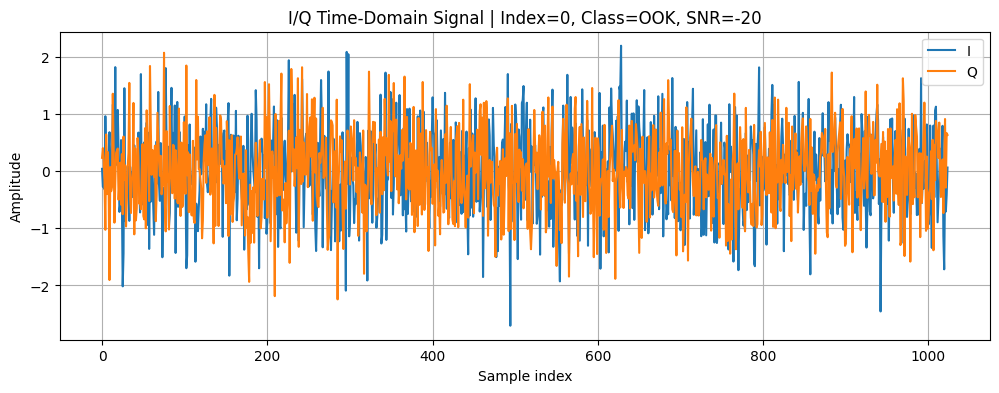

0

In [6]:
# Visualize a signal
a.vis_signal()

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Reduced Dataset

- [Back to Table of Contents](#table-of-contents)

</div>

##### **SUMMARY**:
- From the above observations and uniform distribution of the highest SNR (30) signals across all signal modulation types, the reduced dataset will only house these signals at 1,000 signals per modulation type which makes up ~1% of the original dataset.  For now, this is training a model on "perfect" data, and will introduce more noisy signals as tangible progress and understanding is made.
- The reduced dataset is saved as `../Datasets/highest_snr_reduced_df.hdf5`

In [7]:
# Create the reduced dataset with only the highest SNR (30)
# Ensure the distribution is still uniform
a.create_highest_snr_reduced_hdf5()

highest_snr_reduced_df.hdf5 file created successfully!
Output filepath: ../Datasets/highest_snr_reduced_df.hdf5
Highest SNR: 30
Signals per modulation type: 1000
Total reduced signals: 24000

    modulation_id modulation_type  num_signals  percentage
0               0             OOK         1000        4.17
1               1            4ASK         1000        4.17
2               2            8ASK         1000        4.17
3               3            BPSK         1000        4.17
4               4            QPSK         1000        4.17
5               5            8PSK         1000        4.17
6               6           16PSK         1000        4.17
7               7           32PSK         1000        4.17
8               8          16APSK         1000        4.17
9               9          32APSK         1000        4.17
10             10          64APSK         1000        4.17
11             11         128APSK         1000        4.17
12             12           16QAM        